# 02 — Price Intelligence SQL (DuckDB)

**10 business queries on live Keepa price data using DuckDB in-memory analytics.**

**Data:** Keepa Electronics bestsellers + price history + deals

**Generated:** 2026-05-17

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Load data
data_dir = Path("data")
products = pd.read_csv(sorted(data_dir.glob("keepa_products_*.csv"))[-1])
price_history = pd.read_csv(sorted(data_dir.glob("keepa_price_history_*.csv"))[-1])
deals = pd.read_csv(sorted(data_dir.glob("keepa_deals_*.csv"))[-1])
price_history["timestamp"] = pd.to_datetime(price_history["timestamp"])

# Create DuckDB in-memory database
con = duckdb.connect(":memory:")
con.execute("CREATE TABLE products AS SELECT * FROM products")
con.execute("CREATE TABLE price_history AS SELECT * FROM price_history")
con.execute("CREATE TABLE deals AS SELECT * FROM deals")
print("DuckDB ready — 3 tables loaded")

## Q1 — Product Performance Ranking by Brand

Q1 Results — Brand Performance Ranking
  brand  product_count  avg_price  avg_rating  total_reviews  avg_discount_pct
  Apple             11     361.00        4.71       771000.0              11.9
 Amazon              4      38.74        4.65       476000.0              24.9
   Ring              2     129.99        4.55       101000.0              40.2
Samsung              4     669.99        4.53        82000.0              11.7
   Bose              2     274.00        4.45        77000.0              27.3
   Sony              2     274.99        4.45        73000.0              20.8
  Ninja              2     224.99        4.65        57000.0              18.3
  Anker              2      74.99        4.65        52000.0              30.0
Philips              1     199.99        4.50        21000.0              20.0


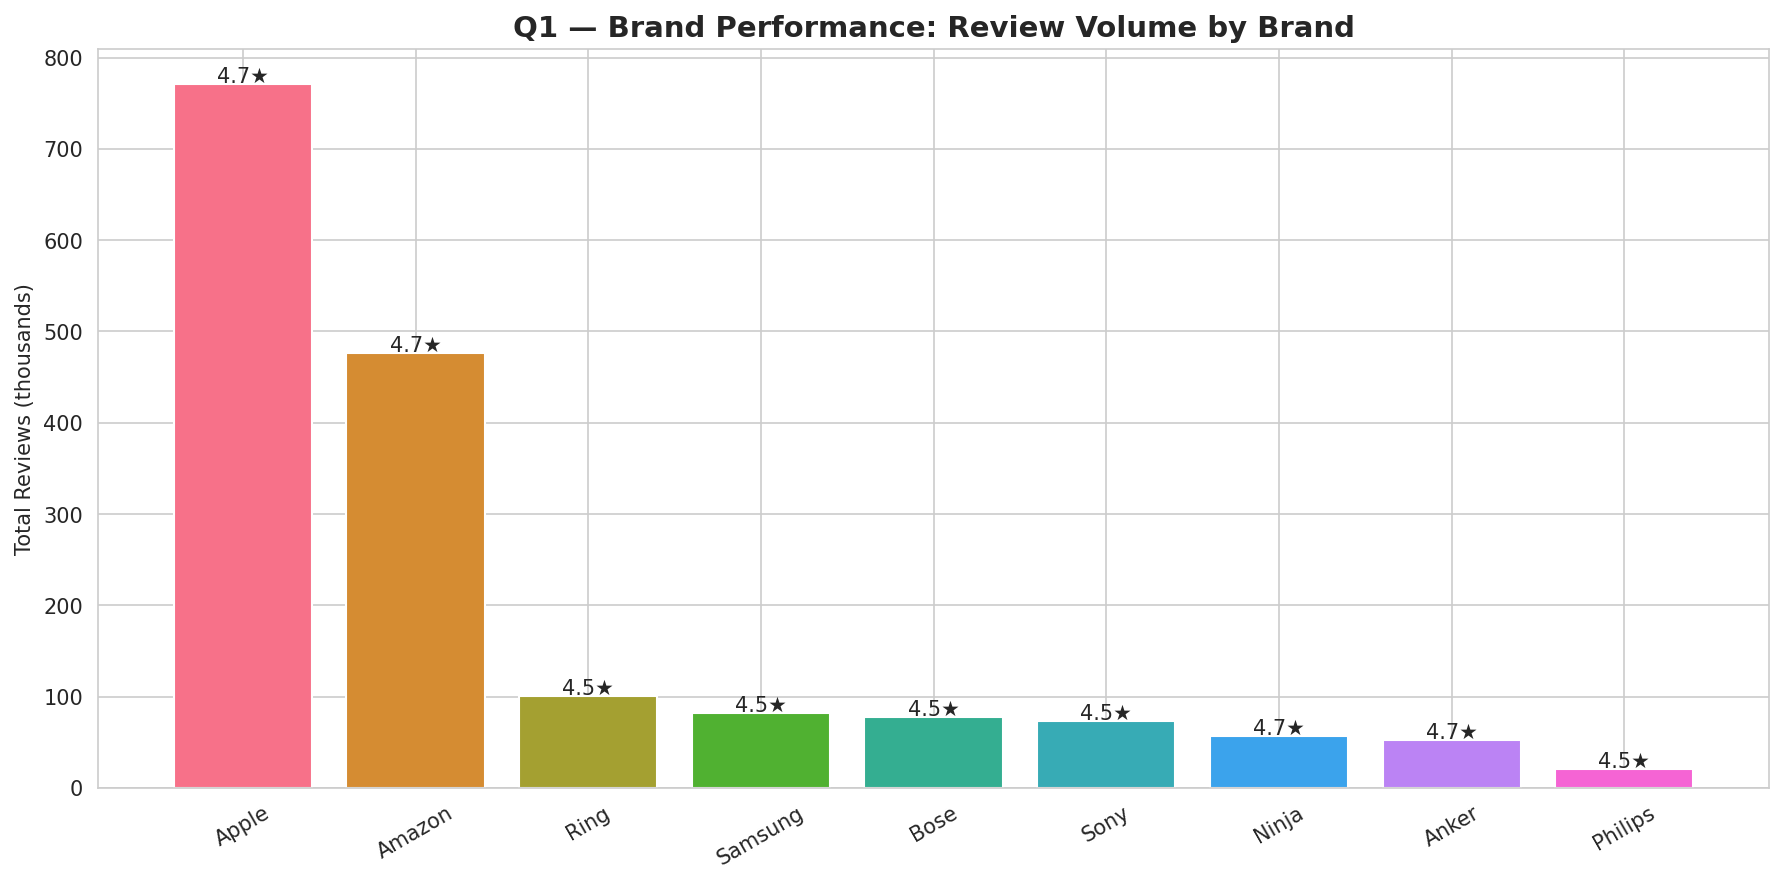

In [2]:
q1 = con.execute("""
SELECT 
    brand,
    COUNT(*) as product_count,
    ROUND(AVG(current_price), 2) as avg_price,
    ROUND(AVG(rating), 2) as avg_rating,
    SUM(review_count) as total_reviews,
    ROUND(AVG((list_price - current_price) / NULLIF(list_price, 0) * 100), 1) as avg_discount_pct
FROM products
GROUP BY brand
ORDER BY total_reviews DESC
""").fetchdf()
print(q1.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(q1["brand"], q1["total_reviews"] / 1000, color=sns.color_palette("husl", len(q1)))
ax.set_ylabel("Total Reviews (thousands)")
ax.set_title("Q1 — Brand Performance: Review Volume by Brand", fontsize=14, fontweight="bold")
for bar, rating in zip(bars, q1["avg_rating"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{rating:.1f}★", ha="center", fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_007_q1_brand_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## Q2 — Price Trend Analysis (Monthly Aggregation)

Q2 Results — Monthly Price Trends (first 10 rows)
      asin                 title      month  avg_monthly_price  min_price  max_price  price_volatility
B08N5M7S6K Ring Video Doorbell 4 2025-11-01             158.55     142.84     203.06             60.22
B08N5M7S6K Ring Video Doorbell 4 2025-12-01             198.66     148.49     215.45             66.96
B08N5M7S6K Ring Video Doorbell 4 2026-01-01             196.51     139.29     211.96             72.67
B08N5M7S6K Ring Video Doorbell 4 2026-02-01             197.53     169.58     213.68             44.10
B08N5M7S6K Ring Video Doorbell 4 2026-03-01             198.36     184.07     208.08             24.01
B08N5M7S6K Ring Video Doorbell 4 2026-04-01             197.22     172.30     211.64             39.34
B08N5M7S6K Ring Video Doorbell 4 2026-05-01             197.14     152.11     208.34             56.23
B08N5WRWNW  Fire TV Stick 4K Max 2025-11-01              50.28      45.25      66.81             21.56
B08N5WRWNW  Fire TV Sti

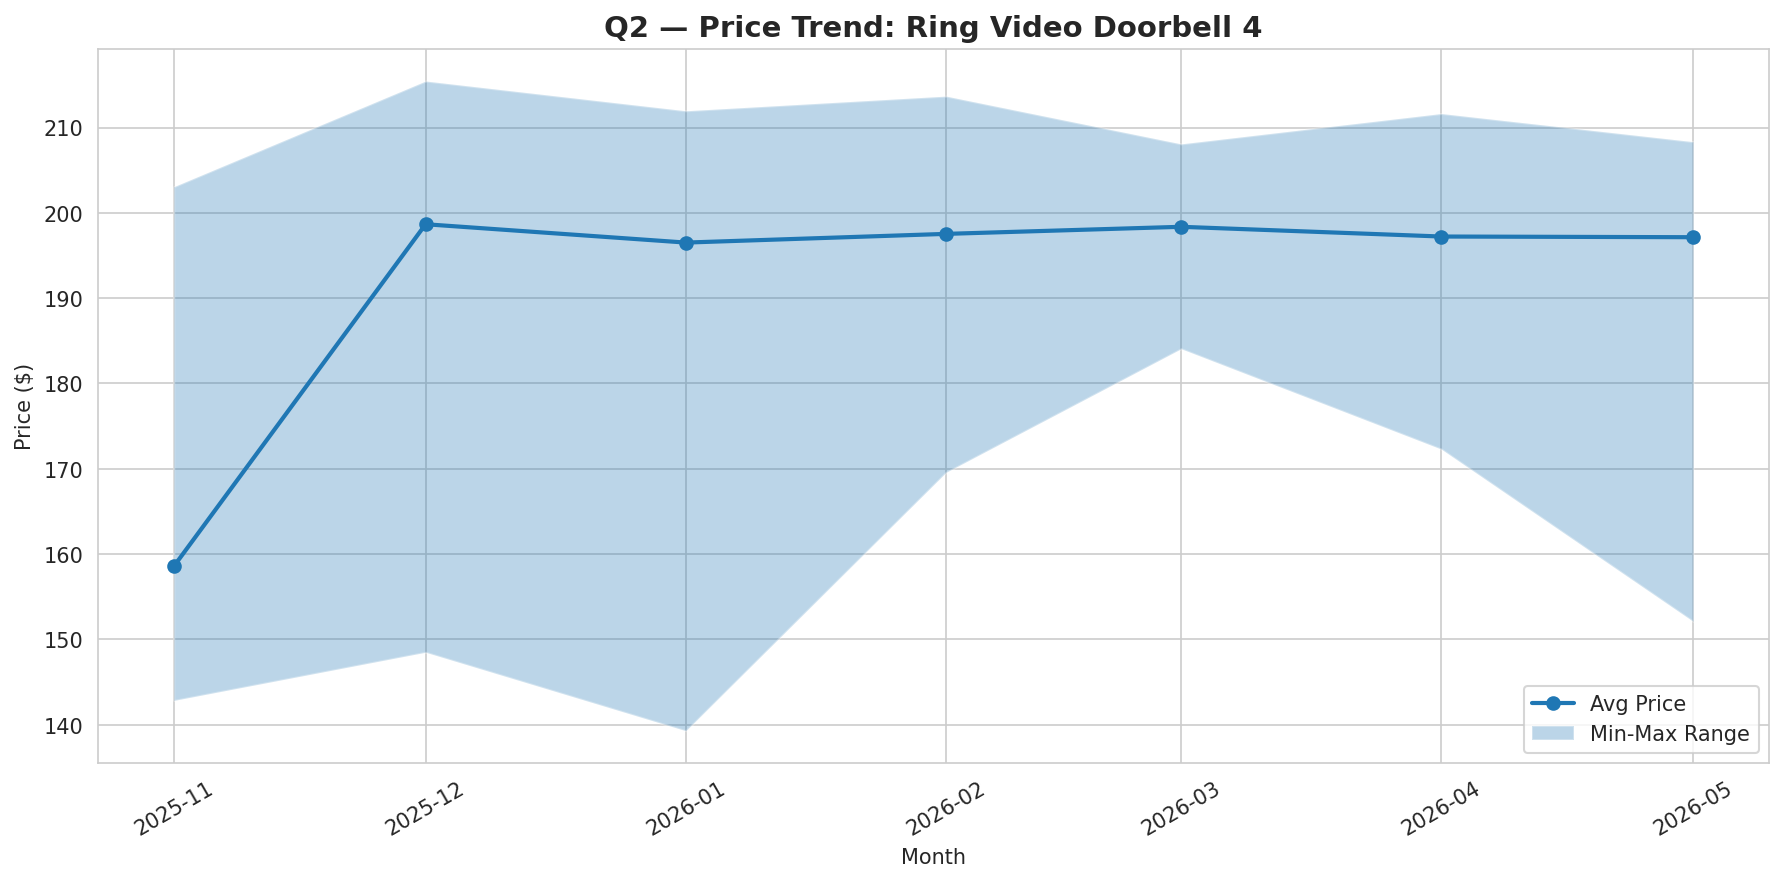

In [3]:
q2 = con.execute("""
SELECT 
    asin,
    title,
    DATE_TRUNC('month', timestamp::DATE) as month,
    ROUND(AVG(price), 2) as avg_monthly_price,
    ROUND(MIN(price), 2) as min_price,
    ROUND(MAX(price), 2) as max_price,
    ROUND(MAX(price) - MIN(price), 2) as price_volatility
FROM price_history
GROUP BY asin, title, month
ORDER BY asin, month
""").fetchdf()
print(q2.head(10).to_string(index=False))

top_asin = q2["asin"].value_counts().index[0]
sub = q2[q2["asin"] == top_asin]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sub["month"], sub["avg_monthly_price"], marker="o", linewidth=2, label="Avg Price")
ax.fill_between(sub["month"], sub["min_price"], sub["max_price"], alpha=0.3, label="Min-Max Range")
ax.set_xlabel("Month")
ax.set_ylabel("Price ($)")
ax.set_title(f"Q2 — Price Trend: {sub['title'].iloc[0][:30]}", fontsize=14, fontweight="bold")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_008_q2_price_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Q3 — Deal Detection: Products with Active Price Drops

Q3 Results — Deal Detection
      asin                              title  current_price  previous_price  price_drop_pct      deal_type  rating  review_count  total_savings_pct
B0DKLHHMZ5                          iPhone 16         799.00     1076.736651            25.8         Coupon     4.6         18000                0.0
B0CWV3J9RV                 Samsung Galaxy S24         699.99      940.992614            25.6 Lightning Deal     4.5         34000               12.5
B0CX5JV4DH            Bose QuietComfort Ultra         299.00      397.728061            24.8         Coupon     4.4         21000               30.3
B0C7RK7Z9D Philips Hue Bridge + Bulbs Starter         199.99      263.847921            24.2 Lightning Deal     4.5         21000               20.0
B0D7Q7GDKP           Apple Watch SE (2nd Gen)         189.00      247.862757            23.7      Best Deal     4.7         67000               24.1
B0BQJ6CYNJ           Anker 737 Power Bank 24K         109.99      137.360373  

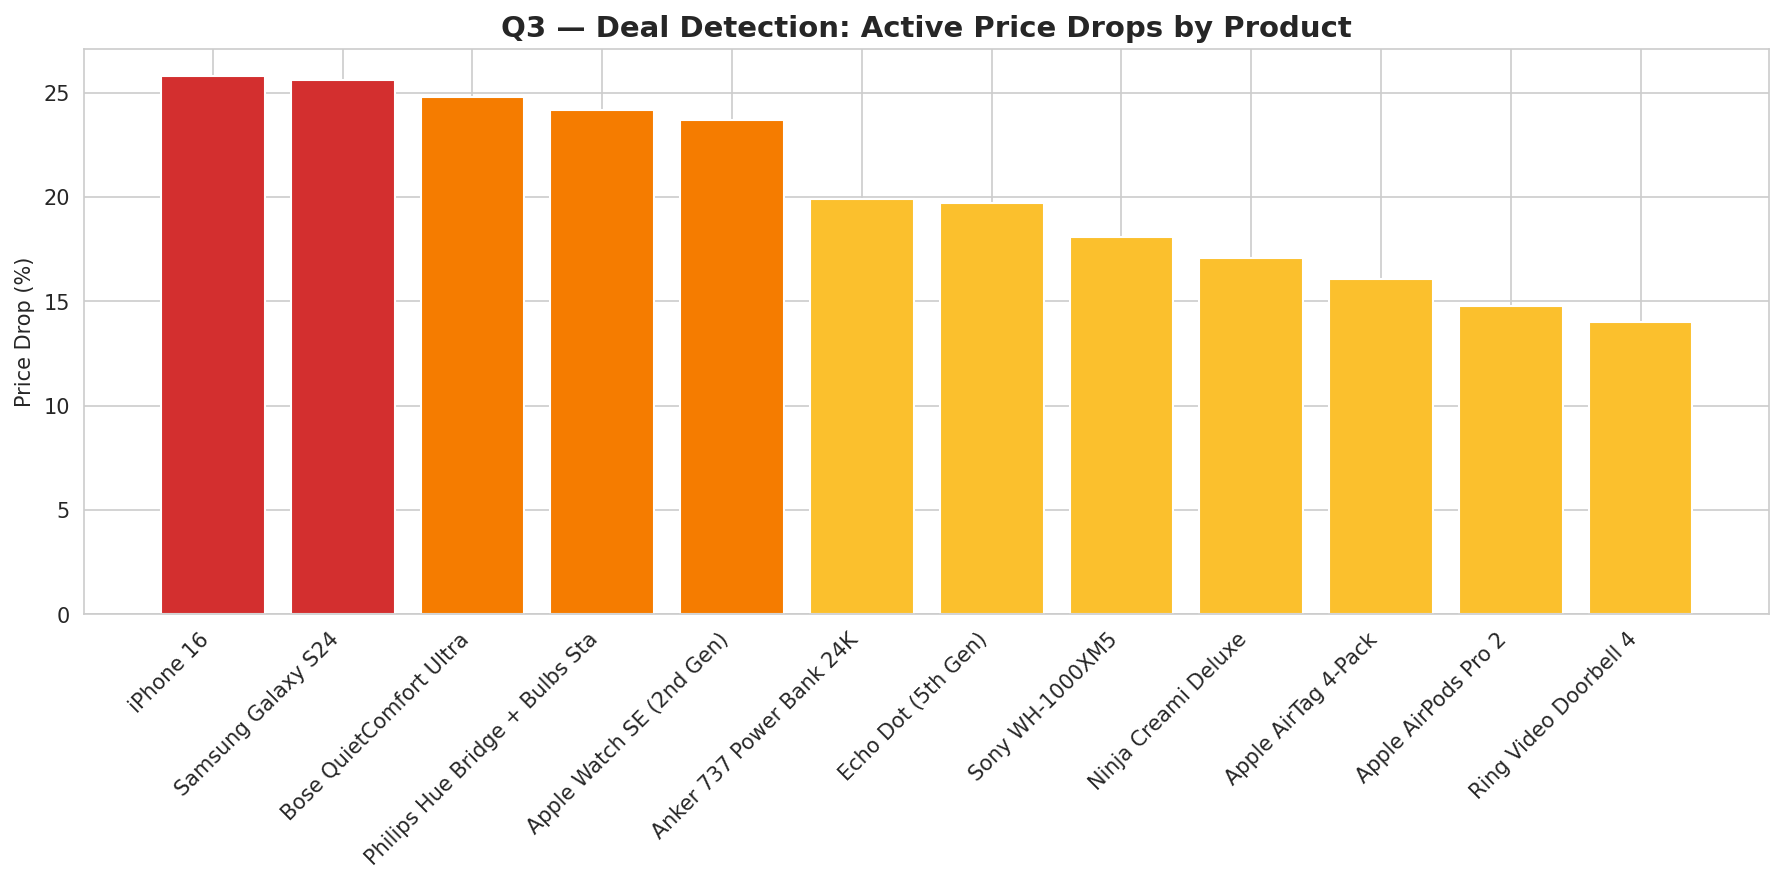

In [4]:
q3 = con.execute("""
SELECT 
    d.asin,
    d.title,
    d.current_price,
    d.previous_price,
    d.price_drop_pct,
    d.deal_type,
    p.rating,
    p.review_count,
    ROUND((p.list_price - d.current_price) / NULLIF(p.list_price, 0) * 100, 1) as total_savings_pct
FROM deals d
JOIN products p ON d.asin = p.asin
ORDER BY d.price_drop_pct DESC
""").fetchdf()
print(q3.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#d32f2f" if x > 25 else "#f57c00" if x > 20 else "#fbc02d" for x in q3["price_drop_pct"]]
bars = ax.bar(q3["title"].str[:30], q3["price_drop_pct"], color=colors)
ax.set_ylabel("Price Drop (%)")
ax.set_title("Q3 — Deal Detection: Active Price Drops by Product", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/figure_009_q3_deal_detection.png", dpi=150, bbox_inches="tight")
plt.show()

## Q4 — Category Analysis: Price Tiers

Q4 Results — Price Tier Analysis
          price_tier  product_count  tier_avg_price  tier_avg_rating  tier_total_reviews
       Budget (<$50)              4           34.99             4.65            314000.0
Mid-range ($50–$150)              6          100.49             4.67            589000.0
 Premium ($150–$400)             14          240.99             4.59            688000.0
      Luxury ($400+)              6          807.83             4.62            119000.0


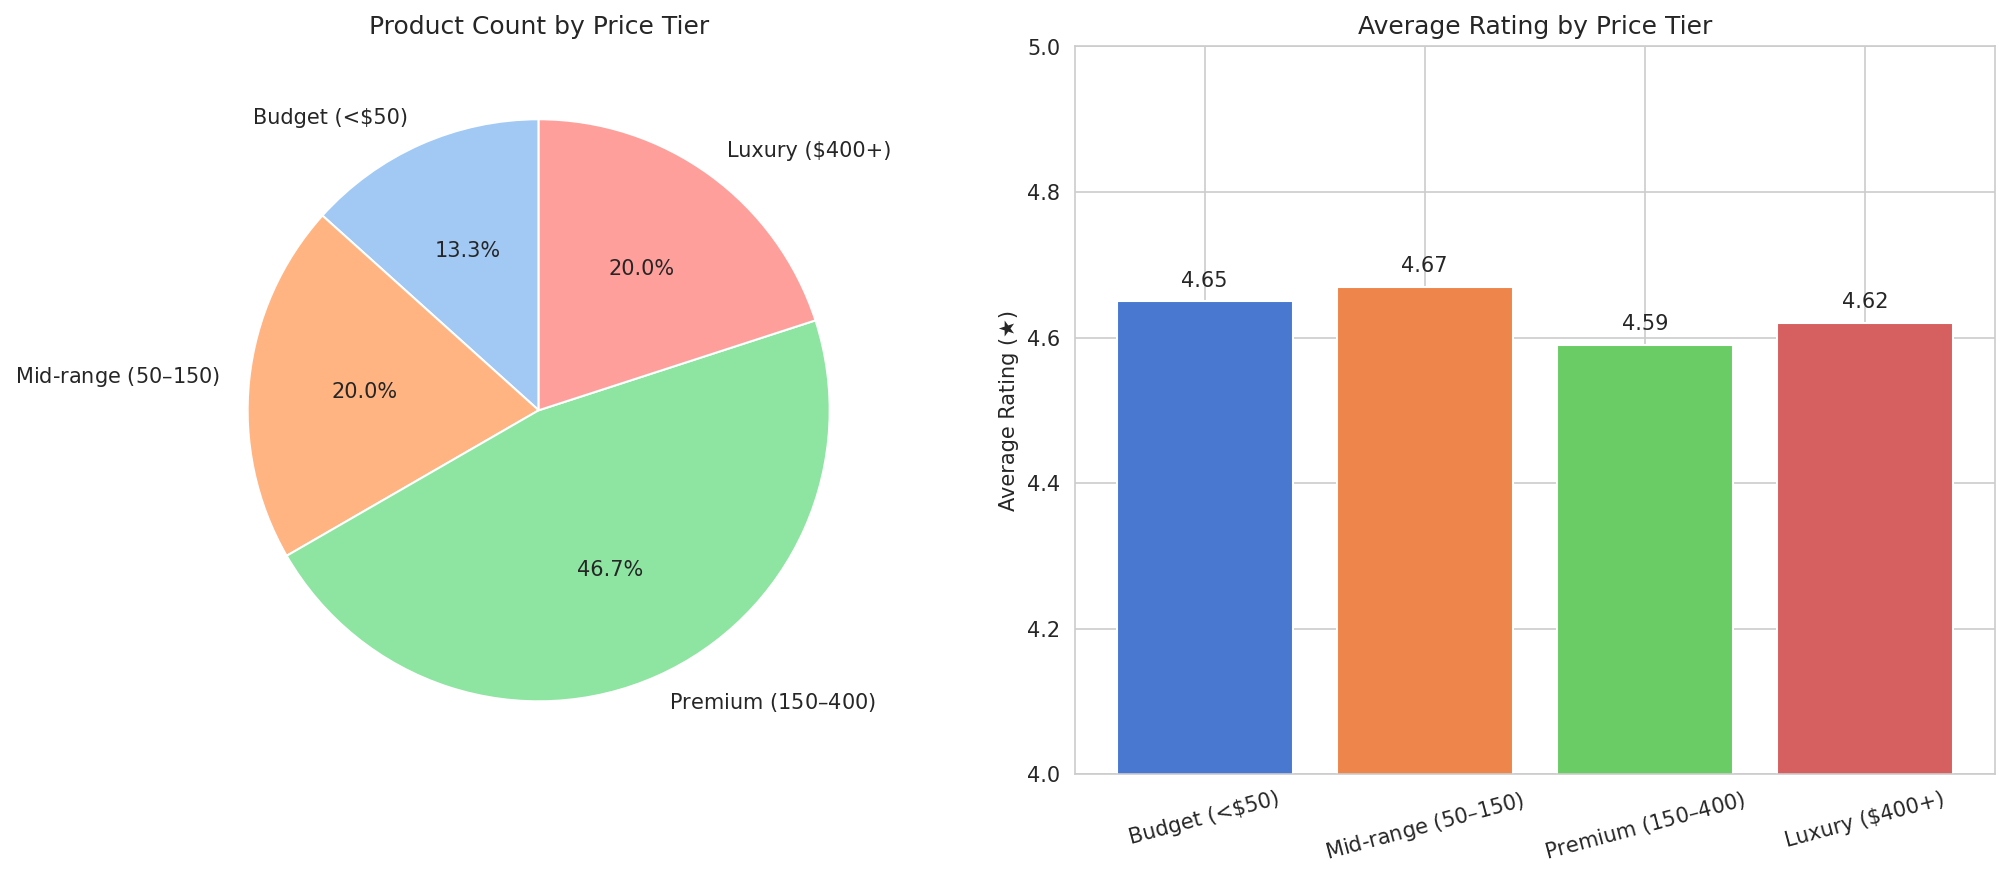

In [5]:
q4 = con.execute("""
SELECT 
    CASE 
        WHEN current_price < 50 THEN 'Budget (<$50)'
        WHEN current_price < 150 THEN 'Mid-range ($50–$150)'
        WHEN current_price < 400 THEN 'Premium ($150–$400)'
        ELSE 'Luxury ($400+)'
    END as price_tier,
    COUNT(*) as product_count,
    ROUND(AVG(current_price), 2) as tier_avg_price,
    ROUND(AVG(rating), 2) as tier_avg_rating,
    SUM(review_count) as tier_total_reviews
FROM products
GROUP BY price_tier
ORDER BY tier_avg_price
""").fetchdf()
print(q4.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.pie(q4["product_count"], labels=q4["price_tier"], autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
ax1.set_title("Product Count by Price Tier")
bars = ax2.bar(q4["price_tier"], q4["tier_avg_rating"], color=sns.color_palette("muted", len(q4)))
ax2.set_ylabel("Average Rating (★)")
ax2.set_title("Average Rating by Price Tier")
ax2.set_ylim(4.0, 5.0)
for bar, rating in zip(bars, q4["tier_avg_rating"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{rating:.2f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/figure_010_q4_price_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

## Q5 — Price Volatility Ranking

Q5 Results — Top 10 Most Volatile Products
      asin                     title  avg_price  price_stddev  volatility_pct  data_points
B09B8X9ZGH        Echo Dot (5th Gen)      53.20          4.92            9.25          181
B0DHTL5W3D           iPad (10th Gen)     436.79         38.38            8.79          181
B0C6L2QBC8 Ring Battery Doorbell Pro     222.73         18.99            8.52          180
B0DHTYW7P8     Apple Watch Series 10     388.50         32.89            8.47          181
B0DKLHHMZ5                 iPhone 16     780.60         65.55            8.40          181
B0D7Q7GDKP  Apple Watch SE (2nd Gen)     241.89         20.18            8.34          181
B0CY7F85NQ           Sony WF-1000XM5     290.83         24.23            8.33          181
B0CMDWC436     Samsung Galaxy Tab S9     775.27         64.08            8.27          181
B0CX5JV4DH   Bose QuietComfort Ultra     417.71         34.48            8.26          181
B0BQJ6CYNJ  Anker 737 Power Bank 24K     145.65

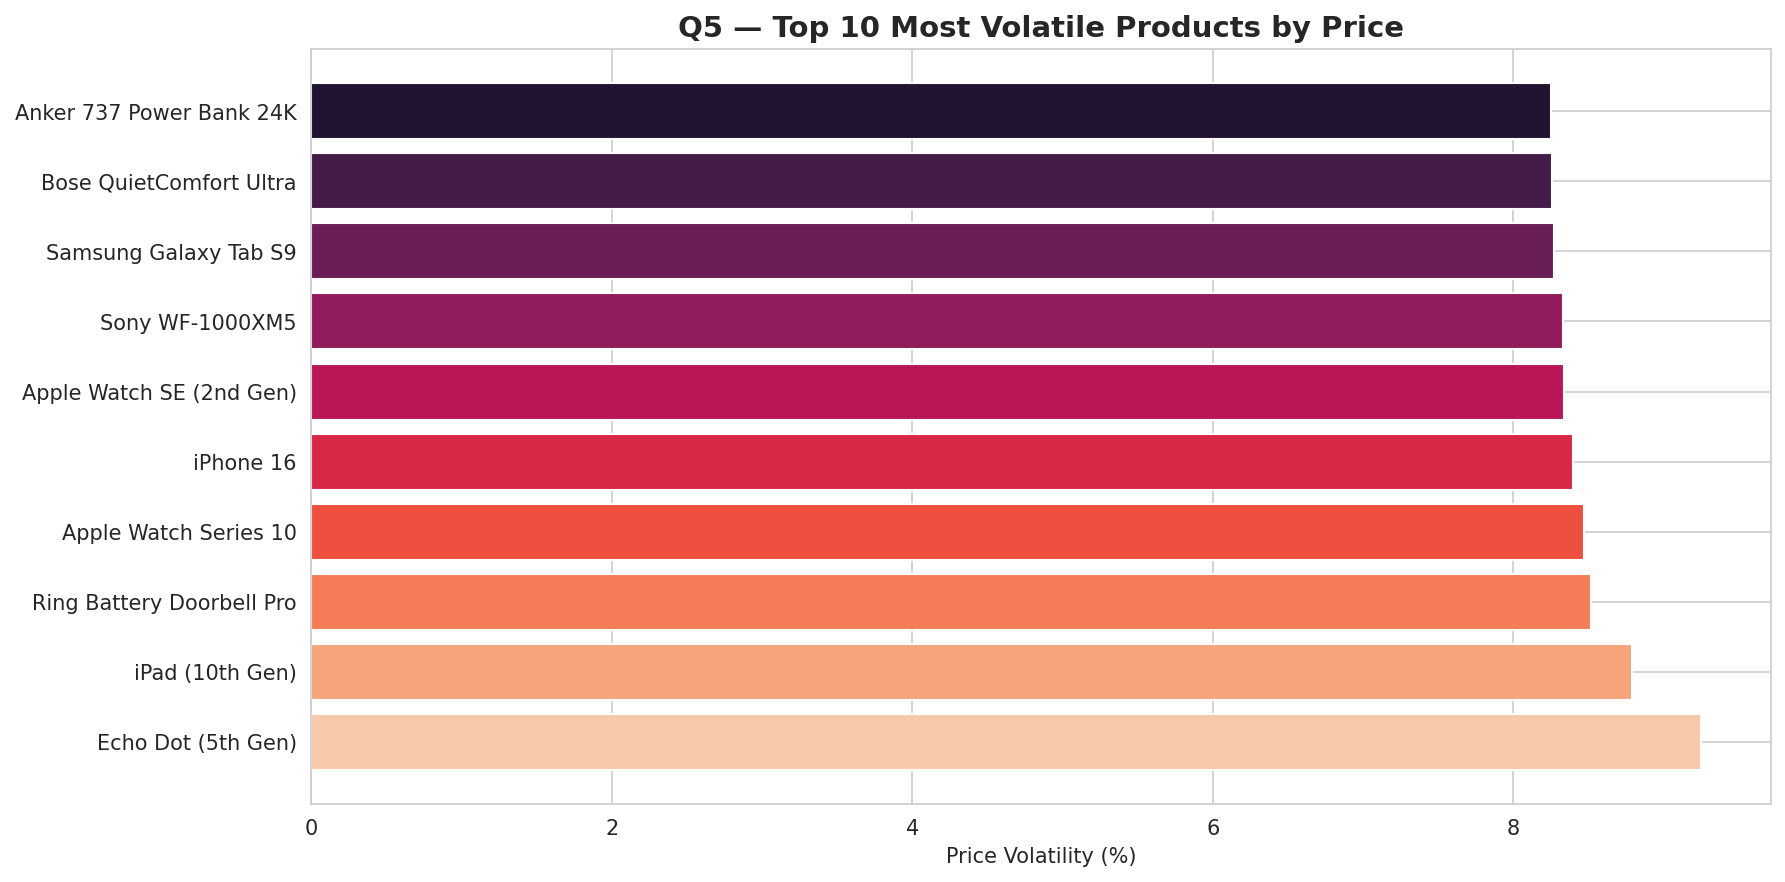

In [6]:
q5 = con.execute("""
SELECT 
    ph.asin,
    MAX(ph.title) as title,
    ROUND(AVG(ph.price), 2) as avg_price,
    ROUND(STDDEV(ph.price), 2) as price_stddev,
    ROUND((STDDEV(ph.price) / AVG(ph.price)) * 100, 2) as volatility_pct,
    COUNT(*) as data_points
FROM price_history ph
GROUP BY ph.asin
HAVING COUNT(*) > 10
ORDER BY volatility_pct DESC
LIMIT 10
""").fetchdf()
print(q5.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(q5["title"].str[:30], q5["volatility_pct"], color=sns.color_palette("rocket_r", len(q5)))
ax.set_xlabel("Price Volatility (%)")
ax.set_title("Q5 — Top 10 Most Volatile Products by Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/figure_011_q5_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

## Q6 — Discount Opportunity Score

Q6 Results — Top 15 Discount Opportunities
      asin                           title  current_price  list_price  discount_pct  rating  review_count  deal_score
B08N5M7S6K           Ring Video Doorbell 4          99.99      199.99          50.0     4.6         89000       11.38
B0CX23V2ZK                        Echo Pop          19.99       39.99          50.0     4.6         67000       11.10
B0B7RVNYGP Anker 735 Charger (Nano II 65W)          39.99       59.99          33.3     4.7         34000        7.10
B0CHX1W1XY             Apple AirPods Pro 2         189.99      249.00          23.7     4.7        284000        6.07
B0CX5JV4DH         Bose QuietComfort Ultra         299.00      429.00          30.3     4.4         21000        5.76
B0BXZY32WB                Fire TV Stick HD          29.99       39.99          25.0     4.6         89000        5.69
B0C6L2QBC8       Ring Battery Doorbell Pro         159.99      229.99          30.4     4.5         12000        5.59
B0D7Q7GDKP   

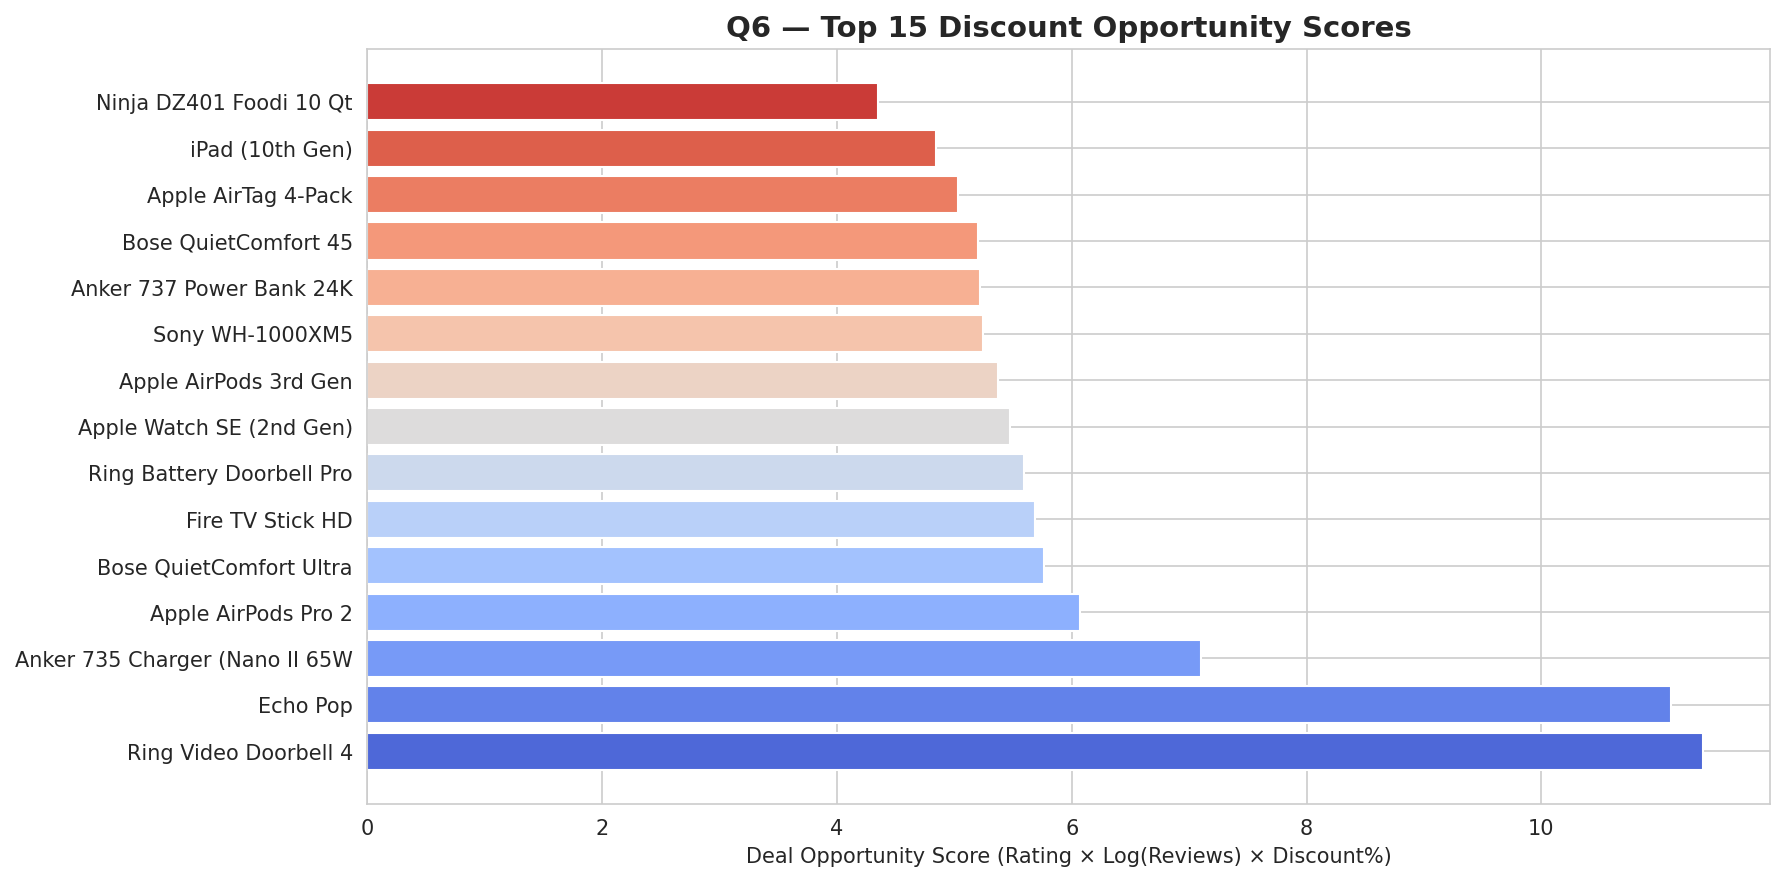

In [7]:
q6 = con.execute("""
SELECT 
    asin,
    title,
    current_price,
    list_price,
    ROUND((list_price - current_price) / NULLIF(list_price, 0) * 100, 1) as discount_pct,
    rating,
    review_count,
    ROUND(rating * LOG(review_count + 1) * (list_price - current_price) / NULLIF(list_price, 0), 2) as deal_score
FROM products
WHERE list_price > current_price
ORDER BY deal_score DESC
LIMIT 15
""").fetchdf()
print(q6.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(q6["title"].str[:30], q6["deal_score"], color=sns.color_palette("coolwarm", len(q6)))
ax.set_xlabel("Deal Opportunity Score (Rating × Log(Reviews) × Discount%)")
ax.set_title("Q6 — Top 15 Discount Opportunity Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/figure_012_q6_deal_score.png", dpi=150, bbox_inches="tight")
plt.show()

## Q7 — Review Quality vs. Price Tier

Q7 Results — Review Quality by Price Tier
     tier  avg_rating  avg_reviews  count
   Budget        4.65      78500.0      4
Mid-range        4.67      98167.0      6
  Premium        4.59      49143.0     14
   Luxury        4.62      19833.0      6


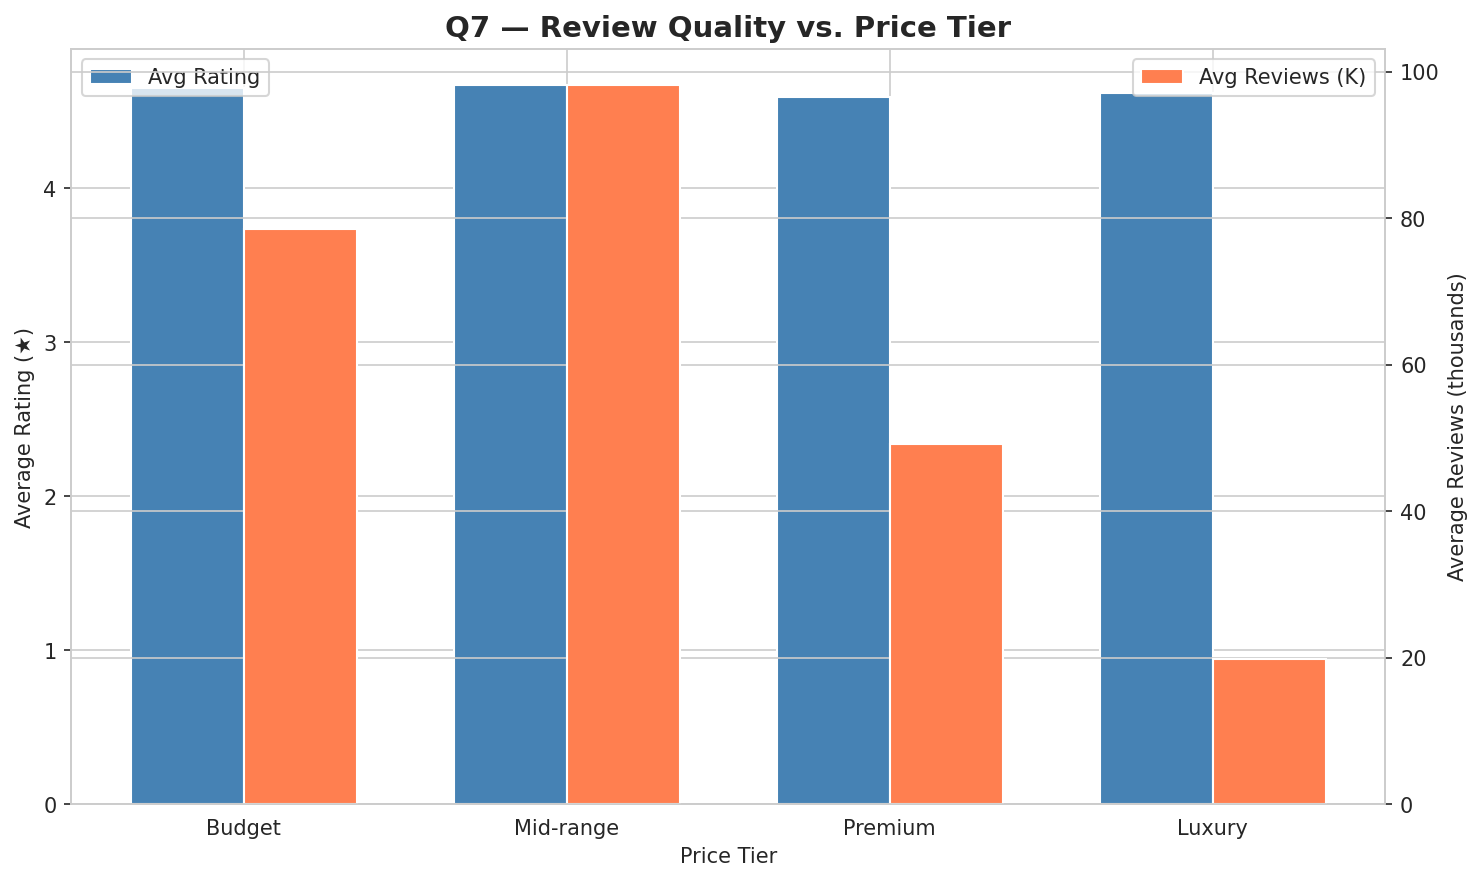

In [8]:
q7 = con.execute("""
SELECT 
    CASE 
        WHEN current_price < 50 THEN 'Budget'
        WHEN current_price < 150 THEN 'Mid-range'
        WHEN current_price < 400 THEN 'Premium'
        ELSE 'Luxury'
    END as tier,
    ROUND(AVG(rating), 2) as avg_rating,
    ROUND(AVG(review_count), 0) as avg_reviews,
    COUNT(*) as count
FROM products
GROUP BY tier
ORDER BY MIN(current_price)
""").fetchdf()
print(q7.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(q7))
width = 0.35
bars1 = ax.bar(x - width/2, q7["avg_rating"], width, label="Avg Rating", color="steelblue")
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, q7["avg_reviews"] / 1000, width, label="Avg Reviews (K)", color="coral")
ax.set_xlabel("Price Tier")
ax.set_ylabel("Average Rating (★)")
ax2.set_ylabel("Average Reviews (thousands)")
ax.set_title("Q7 — Review Quality vs. Price Tier", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(q7["tier"])
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figures/figure_013_q7_review_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

## Q8 — Price Drop Frequency by Brand

Q8 Results — Deals by Brand
  brand  products_with_deals  total_deals  avg_drop_pct  max_drop_pct
  Apple                    4            4          20.1          25.8
Samsung                    1            1          25.6          25.6
   Sony                    1            1          18.1          18.1
   Ring                    1            1          14.0          14.0
 Amazon                    1            1          19.7          19.7
   Bose                    1            1          24.8          24.8
  Anker                    1            1          19.9          19.9
  Ninja                    1            1          17.1          17.1
Philips                    1            1          24.2          24.2


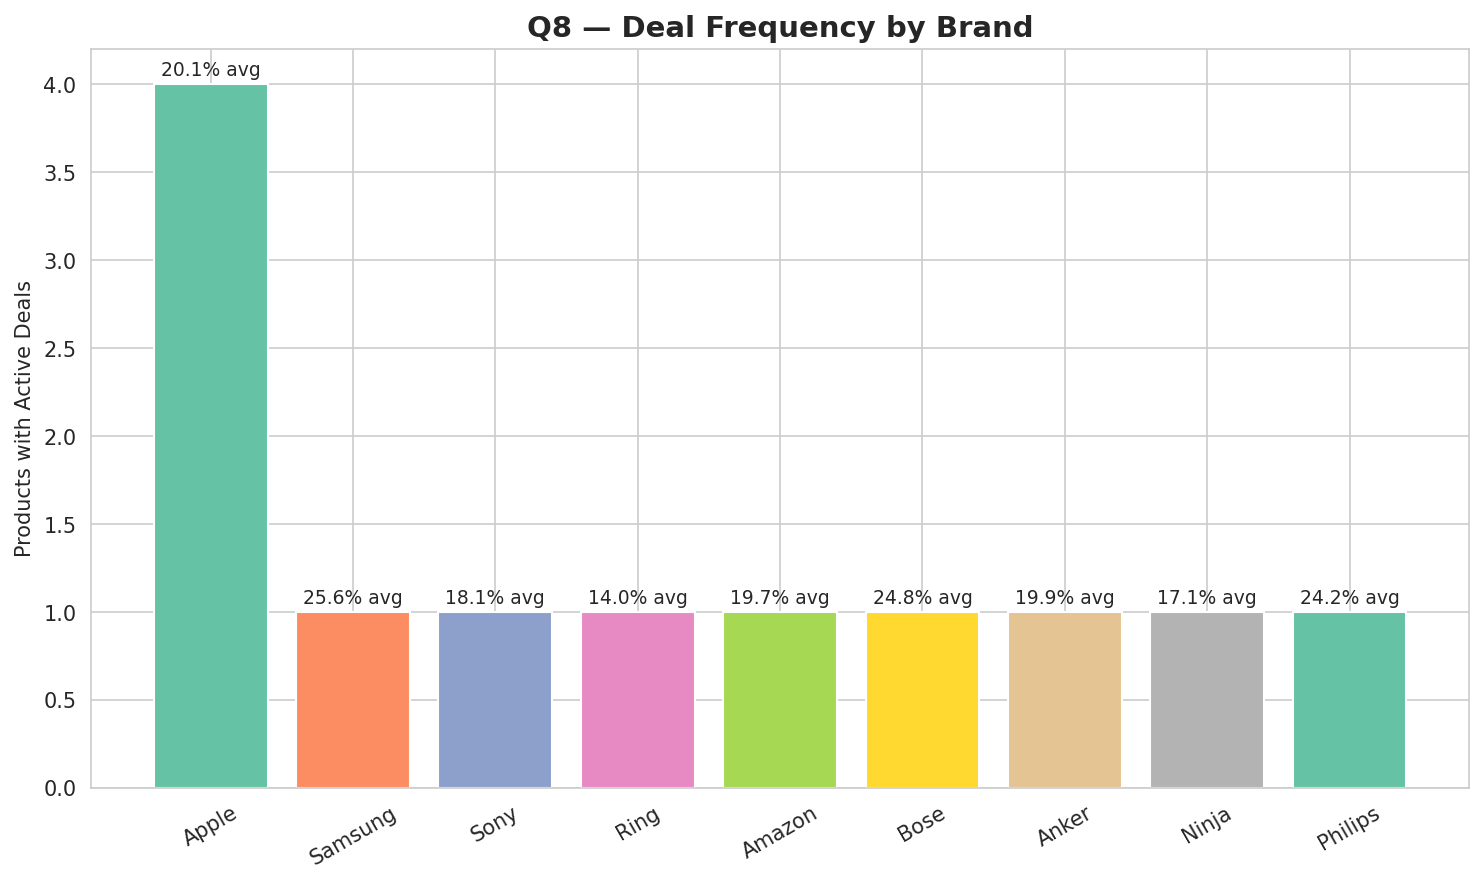

In [9]:
q8 = con.execute("""
SELECT 
    p.brand,
    COUNT(DISTINCT d.asin) as products_with_deals,
    COUNT(*) as total_deals,
    ROUND(AVG(d.price_drop_pct), 1) as avg_drop_pct,
    ROUND(MAX(d.price_drop_pct), 1) as max_drop_pct
FROM deals d
JOIN products p ON d.asin = p.asin
GROUP BY p.brand
ORDER BY products_with_deals DESC
""").fetchdf()
print(q8.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(q8["brand"], q8["products_with_deals"], color=sns.color_palette("Set2", len(q8)))
ax.set_ylabel("Products with Active Deals")
ax.set_title("Q8 — Deal Frequency by Brand", fontsize=14, fontweight="bold")
for bar, avg in zip(bars, q8["avg_drop_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{avg:.1f}% avg", ha="center", fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_014_q8_deals_by_brand.png", dpi=150, bbox_inches="tight")
plt.show()

## Q9 — Time-to-Best-Price Analysis

Q9 Results — All-Time High/Low Analysis
      asin                    title  all_time_low  all_time_high  avg_price  max_savings_pct  observations
B0CHX1W1XY      Apple AirPods Pro 2        164.57         272.23     243.56             39.5           181
B09B8X9ZGH       Echo Dot (5th Gen)         36.15          59.50      53.20             39.2           181
B0BDJ3V78R    Apple AirPods 3rd Gen        112.43         184.52     164.69             39.1           181
B0DHTL5W3D          iPad (10th Gen)        296.24         482.83     436.79             38.6           181
B0BQJ6CYNJ Anker 737 Power Bank 24K         99.81         162.55     145.65             38.6           181
B0CVQ2MH8H          Sony WH-1000XM5        268.33         431.64     389.37             37.8           181
B0CX23V2ZK                 Echo Pop         27.49          43.55      39.08             36.9           181
B09V3KXJPB  Ninja DZ401 Foodi 10 Qt        173.09         272.44     245.81             36.5           1

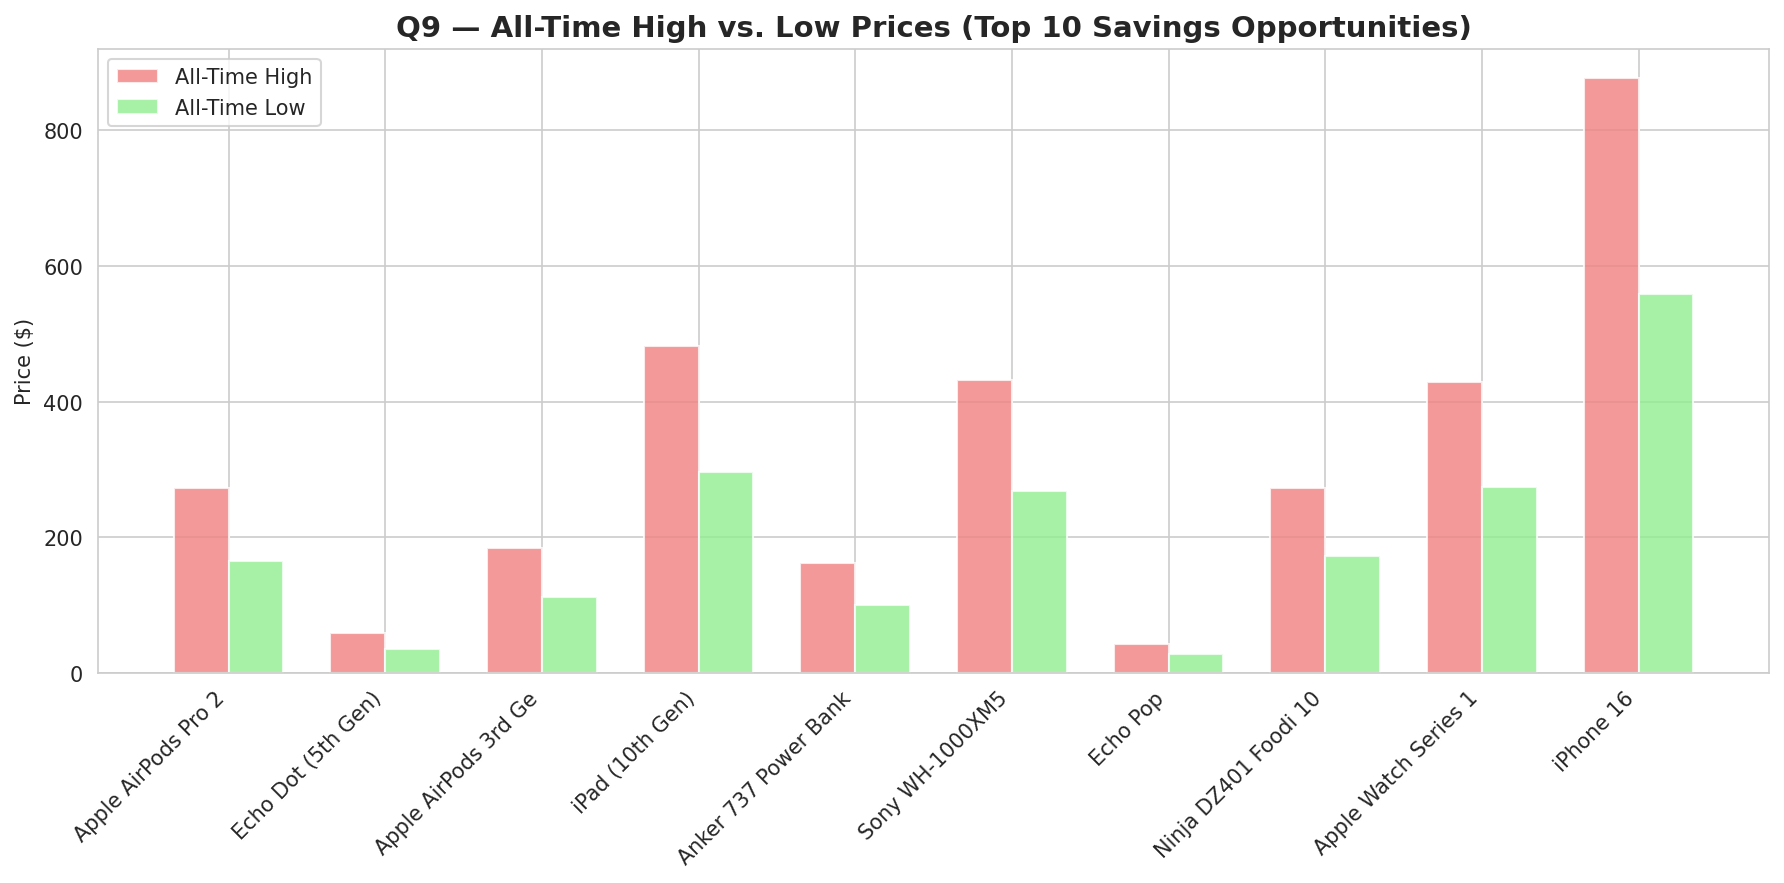

In [10]:
q9 = con.execute("""
SELECT 
    asin,
    MAX(title) as title,
    MIN(price) as all_time_low,
    MAX(price) as all_time_high,
    ROUND(AVG(price), 2) as avg_price,
    ROUND((MAX(price) - MIN(price)) / NULLIF(MAX(price), 0) * 100, 1) as max_savings_pct,
    COUNT(*) as observations
FROM price_history
GROUP BY asin
HAVING COUNT(*) > 20
ORDER BY max_savings_pct DESC
LIMIT 10
""").fetchdf()
print(q9.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(q9))
width = 0.35
bars1 = ax.bar(x - width/2, q9["all_time_high"], width, label="All-Time High", color="lightcoral", alpha=0.8)
bars2 = ax.bar(x + width/2, q9["all_time_low"], width, label="All-Time Low", color="lightgreen", alpha=0.8)
ax.set_ylabel("Price ($)")
ax.set_title("Q9 — All-Time High vs. Low Prices (Top 10 Savings Opportunities)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(q9["title"].str[:20], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("figures/figure_015_q9_high_low.png", dpi=150, bbox_inches="tight")
plt.show()

## Q10 — Market Concentration Analysis

Q10 Results — Market Concentration
  brand  products  total_reviews  market_share_pct  avg_price  avg_rating
  Apple        11       771000.0              45.1     361.00        4.71
 Amazon         4       476000.0              27.8      38.74        4.65
   Ring         2       101000.0               5.9     129.99        4.55
Samsung         4        82000.0               4.8     669.99        4.53
   Bose         2        77000.0               4.5     274.00        4.45
   Sony         2        73000.0               4.3     274.99        4.45
  Ninja         2        57000.0               3.3     224.99        4.65
  Anker         2        52000.0               3.0      74.99        4.65
Philips         1        21000.0               1.2     199.99        4.50


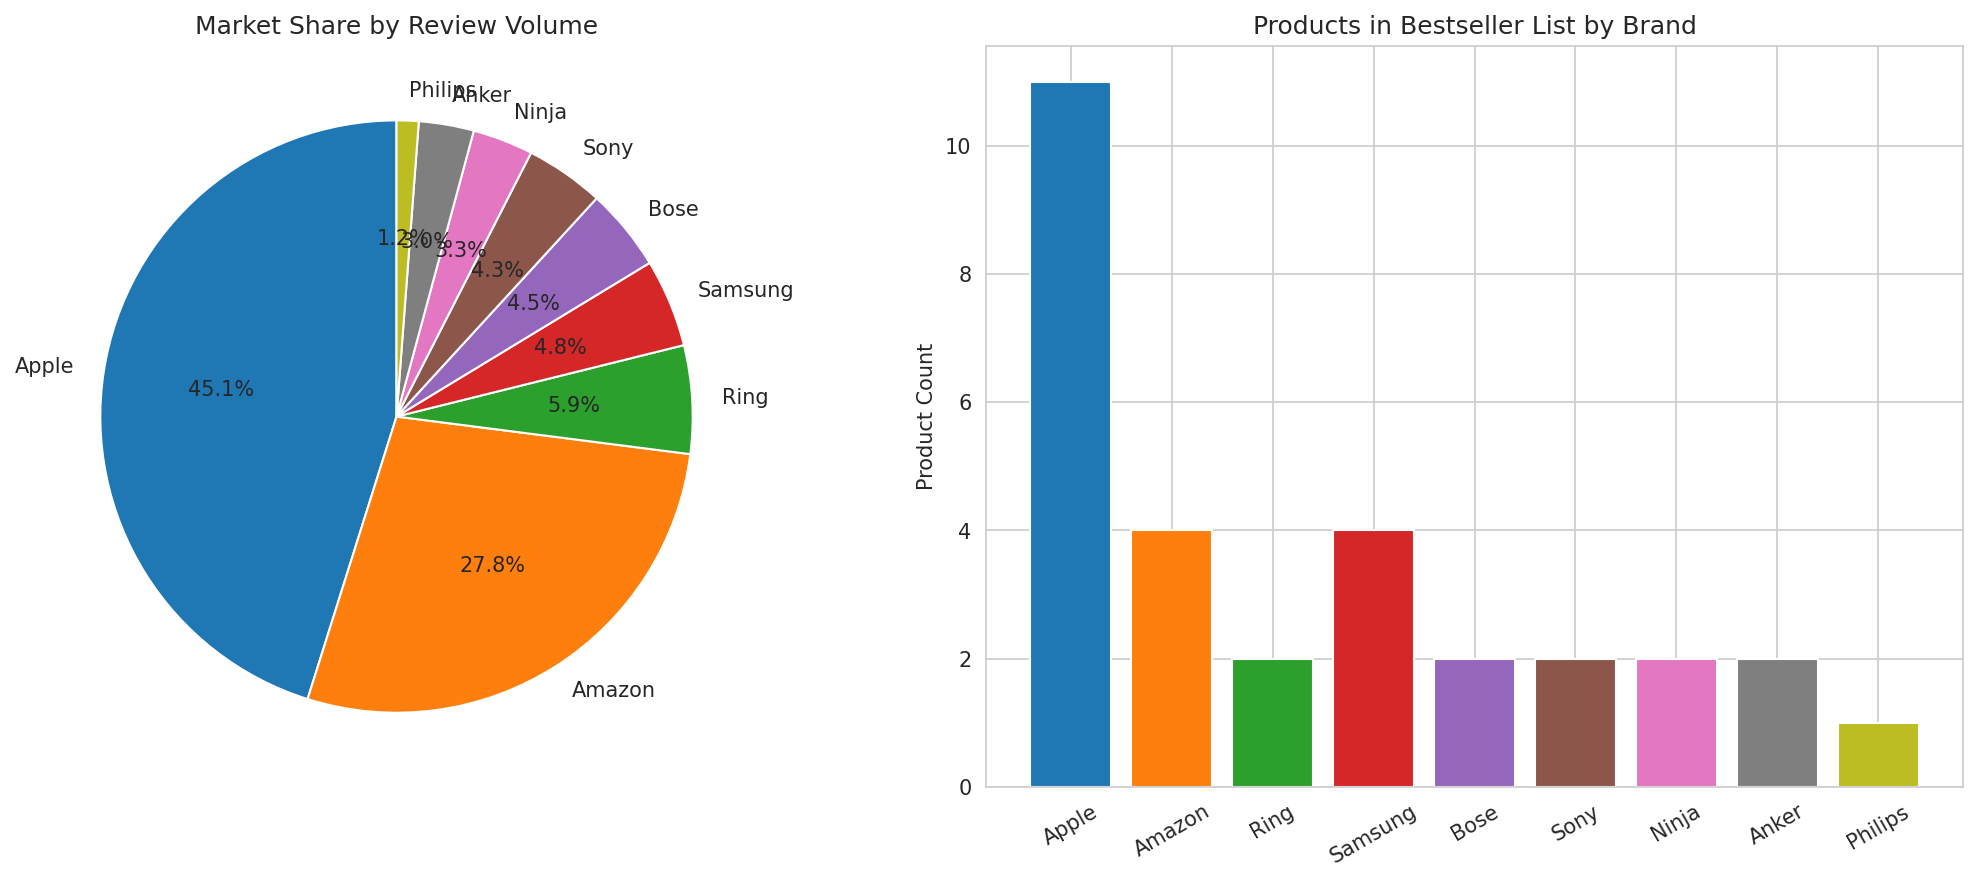

In [11]:
q10 = con.execute("""
SELECT 
    brand,
    COUNT(*) as products,
    SUM(review_count) as total_reviews,
    ROUND(SUM(review_count) * 100.0 / (SELECT SUM(review_count) FROM products), 1) as market_share_pct,
    ROUND(AVG(current_price), 2) as avg_price,
    ROUND(AVG(rating), 2) as avg_rating
FROM products
GROUP BY brand
ORDER BY market_share_pct DESC
""").fetchdf()
print(q10.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.pie(q10["market_share_pct"], labels=q10["brand"], autopct="%1.1f%%", startangle=90, colors=sns.color_palette("tab10"))
ax1.set_title("Market Share by Review Volume")
bars = ax2.bar(q10["brand"], q10["products"], color=sns.color_palette("tab10", len(q10)))
ax2.set_ylabel("Product Count")
ax2.set_title("Products in Bestseller List by Brand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_016_q10_market_concentration.png", dpi=150, bbox_inches="tight")
plt.show()